## 1.Environment setup

In [1]:
pip install rapidfuzz

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# 1. SETUP — FAST, LIGHTWEIGHT, KAGGLE-FRIENDLY
# ============================================================
import os
import re
import gc
import time
import math
import warnings
from pathlib import Path
from collections import defaultdict, Counter

import pandas as pd
import numpy as np

warnings.filterwarnings("ignore")

# Optional high-performance dataframe engine.
try:
    import polars as pl
    HAS_POLARS = True
except Exception:
    HAS_POLARS = False

# Fast string similarity library. Kaggle commonly has it installed.
try:
    from rapidfuzz import fuzz
    HAS_RAPIDFUZZ = True
except Exception:
    HAS_RAPIDFUZZ = False

print("Environment ready")
print("Polars:", HAS_POLARS)
print("RapidFuzz:", HAS_RAPIDFUZZ)

Environment ready
Polars: False
RapidFuzz: True


## 2. Locate the dataset automatically

Kaggle mounts datasets under `/kaggle/input/<dataset-slug>/`.

We will **search rather than hard-code a single versioned path**, so the notebook remains reusable if the dataset version changes.

The official challenge format uses TSV files. In particular, the ground-truth file contains a Source 1 ID and a comma-separated list of matching Source 2/3 IDs.

In [3]:
import os
from pathlib import Path

# Set DATA_ROOT to your SageMaker dataset directory
DATA_ROOT = Path(os.path.expanduser('~/student_resource/dataset'))

print("\nSelected DATA_ROOT:", DATA_ROOT)

# List all files inside the directory
all_files = sorted(DATA_ROOT.rglob("*"))
for f in all_files:
    if f.is_file():
        print(" -", f.relative_to(DATA_ROOT))



Selected DATA_ROOT: /home/sagemaker-user/student_resource/dataset
 - test/test_source1.tsv
 - test/test_source2.tsv
 - test/test_source3.tsv
 - test/test_source_1.xlsx
 - train/train_ground_truth.tsv
 - train/train_source1.tsv
 - train/train_source2.tsv
 - train/train_source3.tsv


## 3. Confirm the challenge file structure

A crucial detail is that these are **tab-separated files**. Reading them as comma-separated CSVs can collapse the entire row into one column.

In [4]:
# ============================================================
# 3. RESOLVE TRAIN / TEST PATHS
# ============================================================
def find_file(filename):
    hits = list(DATA_ROOT.rglob(filename))
    if not hits:
        raise FileNotFoundError(f"Could not find {filename}")
    return hits[0]

FILES = {
    "train_s1": find_file("train_source1.tsv"),
    "train_s2": find_file("train_source2.tsv"),
    "train_s3": find_file("train_source3.tsv"),
    "ground_truth": find_file("train_ground_truth.tsv"),
    "test_s1": find_file("test_source1.tsv"),
    "test_s2": find_file("test_source2.tsv"),
    "test_s3": find_file("test_source3.tsv"),
}

for k, v in FILES.items():
    print(f"{k:14s} -> {v}")

train_s1       -> /home/sagemaker-user/student_resource/dataset/train/train_source1.tsv
train_s2       -> /home/sagemaker-user/student_resource/dataset/train/train_source2.tsv
train_s3       -> /home/sagemaker-user/student_resource/dataset/train/train_source3.tsv
ground_truth   -> /home/sagemaker-user/student_resource/dataset/train/train_ground_truth.tsv
test_s1        -> /home/sagemaker-user/student_resource/dataset/test/test_source1.tsv
test_s2        -> /home/sagemaker-user/student_resource/dataset/test/test_source2.tsv
test_s3        -> /home/sagemaker-user/student_resource/dataset/test/test_source3.tsv


## 4. Dataset size — measure first, optimize second

This challenge is genuinely large. A published dataset card reports roughly **26.4 million records across train and test**, so a conventional pandas `read_csv()` of every file is not the best default. citeturn0search2

We therefore use:

- **Polars** when available
- column projection
- small previews for EDA
- sampling for expensive diagnostics
- vectorized normalization
- blocking instead of Cartesian joins

In [5]:
# ============================================================
# 4. FILE SIZES + SMALL PREVIEWS
# ============================================================
for k, path in FILES.items():
    size_mb = path.stat().st_size / (1024**2)
    print(f"{k:14s} {size_mb:10.1f} MB")

def preview_tsv(path, n=5):
    return pd.read_csv(path, sep="\t", nrows=n)

print("\nTRAIN SOURCE 1 PREVIEW")
display(preview_tsv(FILES["train_s1"]))

print("\nGROUND TRUTH PREVIEW")
display(preview_tsv(FILES["ground_truth"]))

train_s1            200.3 MB
train_s2            466.6 MB
train_s3            480.4 MB
ground_truth        121.1 MB
test_s1             166.9 MB
test_s2             485.9 MB
test_s3             482.6 MB

TRAIN SOURCE 1 PREVIEW


,entity_id,business_name,business_address,country
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India



GROUND TRUTH PREVIEW


,source1_entity_id,matched_entity_ids
0,S1-965667,"S2-681193310,S2-743505751,S3-775321672,S3-1129..."
1,S1-55344266,"S2-249013014,S2-197070651,S3-478195123,S3-3843..."
2,S1-343815751,"S2-790675320,S2-479876582,S3-878454467"
3,S1-656753428,"S2-153058913,S2-24659151,S3-679606215"
4,S1-102811957,"S2-478959098,S2-553508714,S2-625774905,S3-7280..."


## 5. Load only what we need

For this challenge, the core fields are:

- `entity_id`
- `business_name`
- `business_address`
- `country`

The ground truth contains:

- `source1_entity_id`
- `matched_entity_ids`

Keeping the schema narrow reduces memory pressure and makes subsequent operations faster.

In [6]:
# ============================================================
# 5. SCHEMA CHECK
# ============================================================
CORE_COLS = ["entity_id", "business_name", "business_address", "country"]

for name in ["train_s1", "train_s2", "train_s3", "test_s1", "test_s2", "test_s3"]:
    df = pd.read_csv(FILES[name], sep="\t", nrows=3)
    print(f"\n{name}")
    print(df.dtypes)
    print("columns:", list(df.columns))


train_s1
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']

train_s2
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']

train_s3
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']

test_s1
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address', 'country']

test_s2
entity_id           object
business_name       object
business_address    object
country             object
dtype: object
columns: ['entity_id', 'business_name', 'business_address'

## 6. Fast exploratory sample

Full-scale EDA on tens of millions of rows is usually unnecessary.

Instead, we take a reproducible sample from each source and inspect:

- missingness
- country distribution
- text lengths
- duplicate normalized values
- example noise patterns

This gives us useful structural information without turning EDA into the slowest part of the notebook.

In [7]:
# ============================================================
# 6. SAMPLE-BASED EDA
# ============================================================
SAMPLE_N = 50_000
RANDOM_STATE = 42

def sample_tsv(path, n=SAMPLE_N, seed=RANDOM_STATE):
    return pd.read_csv(
        path,
        sep="\t",
        usecols=CORE_COLS,
        nrows=n
    )

eda_s1 = sample_tsv(FILES["train_s1"])
eda_s2 = sample_tsv(FILES["train_s2"])
eda_s3 = sample_tsv(FILES["train_s3"])

for label, df in [("S1", eda_s1), ("S2", eda_s2), ("S3", eda_s3)]:
    print(f"\n===== {label} =====")
    print("rows:", len(df))
    print("missing:")
    display(df.isna().mean().mul(100).round(2).to_frame("missing_%"))
    print("countries:")
    display(df["country"].value_counts(dropna=False).head(15).to_frame("count"))


===== S1 =====
rows: 50000
missing:


,missing_%
entity_id,0.0
business_name,0.0
business_address,0.0
country,0.0


countries:


,count
country,
US,29965
India,20035



===== S2 =====
rows: 50000
missing:


...

,count
country,
US,30097
India,19903



===== S3 =====
rows: 50000
missing:


,missing_%
entity_id,0.00
business_name,0.00
business_address,3.48
country,0.00


countries:


,count
country,
US,29790
India,20210


## 7. Visualize the sample

The following compact dashboard gives us a quick feel for the data.

Because the challenge is entity resolution rather than classical classification, the most useful first plots are:

1. records by country
2. business-name length
3. address length
4. missing-value rates

These are sampled visualizations, not estimates intended to replace the full dataset statistics.

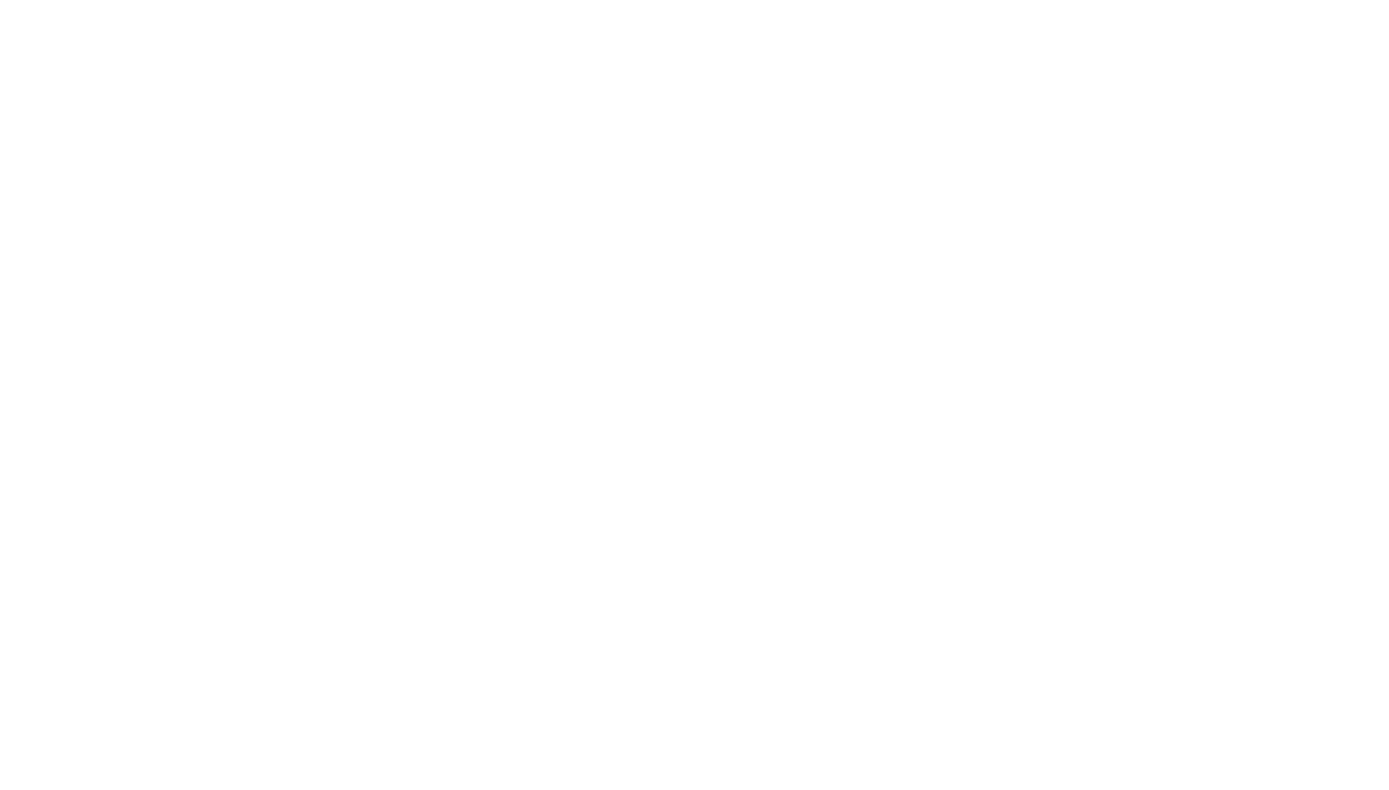

In [8]:
# ============================================================
# 7. QUICK VISUAL DASHBOARD
# ============================================================
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(14, 8))

ax1 = fig.add_subplot(2, 2, 1)
eda_s1["country"].value_counts().head(10).plot(kind="bar", ax=ax1)
ax1.set_title("S1 Sample — Country Distribution")
ax1.set_ylabel("Records")
ax1.tick_params(axis="x", rotation=45)

ax2 = fig.add_subplot(2, 2, 2)
eda_s1["business_name"].fillna("").str.len().clip(upper=100).plot(kind="hist", bins=40, ax=ax2)
ax2.set_title("Business Name Length")
ax2.set_xlabel("Characters")

ax3 = fig.add_subplot(2, 2, 3)
eda_s1["business_address"].fillna("").str.len().clip(upper=250).plot(kind="hist", bins=40, ax=ax3)
ax3.set_title("Business Address Length")
ax3.set_xlabel("Characters")

ax4 = fig.add_subplot(2, 2, 4)
miss = eda_s1.isna().mean().mul(100)
miss.plot(kind="bar", ax=ax4)
ax4.set_title("Missingness — S1 Sample")
ax4.set_ylabel("%")

plt.tight_layout()
plt.show()

## 8. Build robust text normalization

Business names and addresses can differ because of:

- punctuation
- case
- legal suffixes
- `&` versus `and`
- abbreviations
- whitespace
- Unicode variations
- transliteration/noisy formatting

We therefore maintain **multiple representations** instead of destroying information with one aggressive normalization step.

### Representations

- `norm_name`: conservative normalized name
- `compact_name`: whitespace-free normalized name
- `norm_address`: normalized address
- `compact_address`: compact address
- token signatures for blocking

This is especially useful because a single blocking key can create false negatives.

In [9]:
# ============================================================
# 8. NORMALIZATION FUNCTIONS
# ============================================================
LEGAL_SUFFIXES = {
    "incorporated", "inc", "corporation", "corp",
    "limited", "ltd", "llc", "llp",
    "private", "pvt", "company", "co",
    "limitedliabilitycompany"
}

def normalize_text(x):
    if pd.isna(x):
        return ""
    x = str(x).lower()
    x = x.replace("&", " and ")
    x = re.sub(r"[^a-z0-9\s]", " ", x)
    x = re.sub(r"\s+", " ", x).strip()
    return x

def normalize_name(x):
    s = normalize_text(x)
    tokens = [t for t in s.split() if t not in LEGAL_SUFFIXES]
    return " ".join(tokens)

def normalize_address(x):
    return normalize_text(x)

def compact(s):
    return re.sub(r"\s+", "", s)

def token_signature(s):
    return " ".join(sorted(set(s.split())))

for df in [eda_s1]:
    df["norm_name"] = df["business_name"].map(normalize_name)
    df["norm_address"] = df["business_address"].map(normalize_address)
    df["compact_name"] = df["norm_name"].map(compact)
    df["compact_address"] = df["norm_address"].map(compact)

display(
    eda_s1[
        ["business_name", "norm_name", "business_address", "norm_address"]
    ].head(15)
)

,business_name,norm_name,business_address,norm_address
0,Orelee's Barbershop,orelee s barbershop,"1795 Westchester Drive, High Point, NC",1795 westchester drive high point nc
1,Prime Money,prime money,"17560 Ellis Road, Tahlequah, OK",17560 ellis road tahlequah ok
2,B+ Retail Inc,b retail,"1712 Montebello Avenue, Phoenix, AZ",1712 montebello avenue phoenix az
3,Christ Chapel,christ chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",2100 cameron drive unit apartment g dundalk md
4,Prabhav Business Center,prabhav business center,"797, Lake Town Block A, Kolkata, Howrah, West ...",797 lake town block a kolkata howrah west bengal
5,Custom Wealth Services LLC,custom wealth services,"OH, Columbus, 5559 Orville Avenue",oh columbus 5559 orville avenue
6,Consulting Nyasa Nursing Private Limited,consulting nyasa nursing,"2505, Tower 1, Oakwood, Runwal Greens, Mulund ...",2505 tower 1 oakwood runwal greens mulund gore...
7,Nexus Anchor Rain,nexus anchor rain,"1111 Church Street, Unit 2007, Nashville, TN",1111 church street unit 2007 nashville tn
8,Moore Bitwise Inc,moore bitwise,"337 Oakland Avenue, Michigan City, IN",337 oakland avenue michigan city in
9,Dermatology Green Medicine,dermatology green medicine,"294 Meadowcreek Drive, Unit Unit 2, Village Of...",294 meadowcreek drive unit unit 2 village of p...


## 9. Inspect normalization quality

Normalization should simplify harmless formatting differences without erasing useful identity information.

The table below lets us visually inspect transformations before using them for matching.

If a normalization rule looks too aggressive for your data, modify it here — the rest of the notebook will automatically use the updated functions.

In [10]:
# ============================================================
# 9. NORMALIZATION INSPECTION
# ============================================================
inspection = eda_s1[
    ["business_name", "norm_name", "business_address", "norm_address", "country"]
].copy()

display(inspection.sample(min(25, len(inspection)), random_state=42))

,business_name,norm_name,business_address,norm_address,country
33553,India Devansh Freight Private Limited,india devansh freight,"No.8, 15Th Cross, Davis Road, Near St.Alphonsu...",no 8 15th cross davis road near st alphonsus h...,India
9427,"Gwynne Simpson, DO",gwynne simpson do,"1954 Kresge Drive, Amherst, OH",1954 kresge drive amherst oh,US
199,Kylie's Hair Studio,kylie s hair studio,"15083 County Road 1400, Apache, OK",15083 county road 1400 apache ok,US
12447,4627 Mountain View Street Associates LLC,4627 mountain view street associates,"415 Lower Pigeon Road, Ashcamp, KY",415 lower pigeon road ashcamp ky,US
39489,Grey Montreal PC,grey montreal pc,"Wythe County, 640 Murphyville Road, VA",wythe county 640 murphyville road va,US
42724,Ewing Rocky Launchpad Corp,ewing rocky launchpad,"1654 Desert Oasis Court, Benson, AZ",1654 desert oasis court benson az,US
10822,Tech Marketing Private Limited,tech marketing,"570/472, Virat Nagar, Lucknow, Uttar Pradesh",570 472 virat nagar lucknow uttar pradesh,India
49498,Highland Institute II,highland institute ii,"218 Gold Finch Drive, IA, Corydon",218 gold finch drive ia corydon,US
4144,Complete Arts LLC,complete arts,"3750 Brockport Spencerport Road, Ogden, NY",3750 brockport spencerport road ogden ny,US
36958,Quality Medical Brands LLC,quality medical brands,"Sioux Falls, 1701 Berkshire Boulevard, SD",sioux falls 1701 berkshire boulevard sd,US


## 10. Understand the matching structure

The Source 1 table is the reference side. Source 2 and Source 3 contain noisy records that may correspond to Source 1.

The important consequence is:

> We do **not** need to compare S1 against S1.

We only need candidate links:

```text
S1 → S2
S1 → S3
```

Country is a powerful first-level partition. The published dataset analysis reports that the provided ground truth contains no cross-country matches, while also warning that **France appears in test but not training**. Therefore, we use country as a blocking field but never hard-code the allowed countries.

In [11]:
# ============================================================
# 10. GROUND-TRUTH SUMMARY
# ============================================================
gt = pd.read_csv(FILES["ground_truth"], sep="\t", dtype=str).fillna("")

def split_ids(x):
    if not x:
        return []
    return [v.strip() for v in x.split(",") if v.strip()]

gt["match_list"] = gt["matched_entity_ids"].map(split_ids)
gt["n_matches"] = gt["match_list"].str.len()

print("Ground-truth rows:", len(gt))
print("Singleton / no-match S1:", int((gt["n_matches"] == 0).sum()))
print("S1 with >=1 match:", int((gt["n_matches"] > 0).sum()))
print("Maximum matches for one S1:", int(gt["n_matches"].max()))

display(gt["n_matches"].describe().to_frame("match_count"))

Ground-truth rows: 2206821
Singleton / no-match S1: 123247
S1 with >=1 match: 2083574
Maximum matches for one S1: 11


,match_count
count,2.206821e+06
mean,3.461253e+00
std,1.705323e+00
min,0.000000e+00
25%,2.000000e+00
50%,3.000000e+00
75%,5.000000e+00
max,1.100000e+01


## 11. Learn the match-count distribution

The challenge is not strictly one-to-one.

A Source 1 entity can have:

- no matches
- one match
- several matches

Therefore, a correct pipeline must **not** simply choose the single highest-scoring candidate.

We will score candidates independently and then produce a list for every S1 entity.

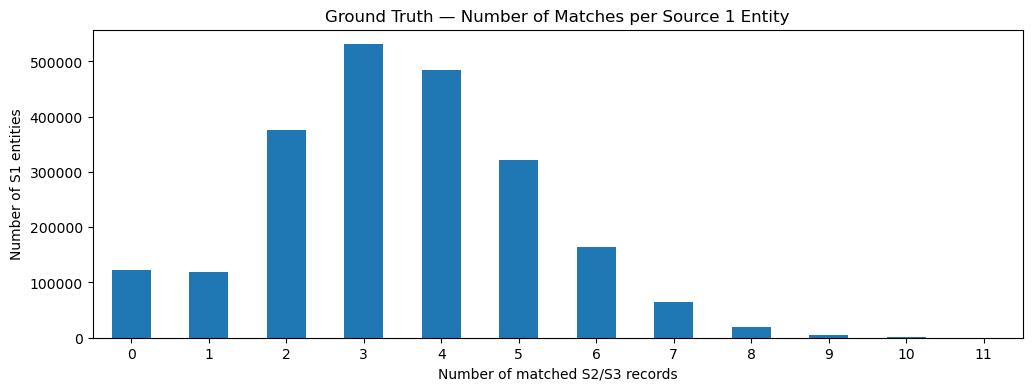

In [12]:
# ============================================================
# 11. MATCH COUNT VISUALIZATION
# ============================================================
counts = gt["n_matches"].value_counts().sort_index()

ax = counts.head(20).plot(kind="bar", figsize=(12, 4))
ax.set_title("Ground Truth — Number of Matches per Source 1 Entity")
ax.set_xlabel("Number of matched S2/S3 records")
ax.set_ylabel("Number of S1 entities")
plt.xticks(rotation=0)
plt.show()

## 12. Exact-match baseline

Before adding fuzzy logic, establish a strong and interpretable baseline.

We test several exact signals:

1. normalized name
2. normalized address
3. normalized name + address
4. compact name + compact address

Exact agreement is particularly valuable in a precision-heavy metric because accidental false merges are expensive.

The official evaluation uses macro-averaged **F₀.₅**, which gives more weight to precision than recall.

In [13]:
# ============================================================
# 12. EXACT MATCH HELPERS
# ============================================================
def prepare_small(df):
    out = df[CORE_COLS].copy()
    out = out.fillna("")
    out["norm_name"] = out["business_name"].map(normalize_name)
    out["norm_address"] = out["business_address"].map(normalize_address)
    out["compact_name"] = out["norm_name"].map(compact)
    out["compact_address"] = out["norm_address"].map(compact)
    out["name_addr_key"] = (
        out["country"].astype(str) + "|" +
        out["compact_name"] + "|" +
        out["compact_address"]
    )
    return out

small_s1 = prepare_small(pd.read_csv(FILES["train_s1"], sep="\t", nrows=20_000, dtype=str))
small_s2 = prepare_small(pd.read_csv(FILES["train_s2"], sep="\t", nrows=50_000, dtype=str))
small_s3 = prepare_small(pd.read_csv(FILES["train_s3"], sep="\t", nrows=50_000, dtype=str))

display(small_s1.head())

,entity_id,business_name,business_address,country,norm_name,norm_address,compact_name,compact_address,name_addr_key
0,S1-925783039,Orelee's Barbershop,"1795 Westchester Drive, High Point, NC",US,orelee s barbershop,1795 westchester drive high point nc,oreleesbarbershop,1795westchesterdrivehighpointnc,US|oreleesbarbershop|1795westchesterdrivehighp...
1,S1-773889195,Prime Money,"17560 Ellis Road, Tahlequah, OK",US,prime money,17560 ellis road tahlequah ok,primemoney,17560ellisroadtahlequahok,US|primemoney|17560ellisroadtahlequahok
2,S1-377745466,B+ Retail Inc,"1712 Montebello Avenue, Phoenix, AZ",US,b retail,1712 montebello avenue phoenix az,bretail,1712montebelloavenuephoenixaz,US|bretail|1712montebelloavenuephoenixaz
3,S1-133037285,Christ Chapel,"2100 Cameron Drive, Unit APARTMENT G, Dundalk, MD",US,christ chapel,2100 cameron drive unit apartment g dundalk md,christchapel,2100camerondriveunitapartmentgdundalkmd,US|christchapel|2100camerondriveunitapartmentg...
4,S1-755362802,Prabhav Business Center,"797, Lake Town Block A, Kolkata, Howrah, West ...",India,prabhav business center,797 lake town block a kolkata howrah west bengal,prabhavbusinesscenter,797laketownblockakolkatahowrahwestbengal,India|prabhavbusinesscenter|797laketownblockak...


## 13. Blocking strategy

A naive comparison would have approximately:

```text
|S1| × (|S2| + |S3|)
```

candidate pairs — far too many.

Instead we generate candidates through several cheap indexes:

### Block A — exact normalized name
`country + compact_name`

### Block B — exact normalized address
`country + compact_address`

### Block C — exact name + address
`country + compact_name + compact_address`

### Block D — token-prefix key
A compact prefix of the strongest name tokens.

The union of these blocks forms the candidate set. The final matcher then applies stricter rules.

In [14]:
# ============================================================
# 13. BLOCKING INDEX
# ============================================================
def build_index(df, column):
    idx = defaultdict(list)
    for row in df.itertuples(index=False):
        key = getattr(row, column)
        if key:
            idx[key].append(row.entity_id)
    return idx

def add_block_keys(df):
    df = df.copy()
    df["country_name_key"] = (
        df["country"].astype(str) + "|" + df["compact_name"]
    )
    df["country_addr_key"] = (
        df["country"].astype(str) + "|" + df["compact_address"]
    )
    df["country_name_addr_key"] = (
        df["country"].astype(str) + "|" +
        df["compact_name"] + "|" + df["compact_address"]
    )
    return df

small_s1 = add_block_keys(small_s1)
small_s2 = add_block_keys(small_s2)
small_s3 = add_block_keys(small_s3)

s2_name_idx = build_index(small_s2, "country_name_key")
s2_addr_idx = build_index(small_s2, "country_addr_key")
s3_name_idx = build_index(small_s3, "country_name_key")
s3_addr_idx = build_index(small_s3, "country_addr_key")

print("S2 name index keys:", len(s2_name_idx))
print("S3 name index keys:", len(s3_name_idx))

S2 name index keys: 44104
S3 name index keys: 45954


## 14. Candidate generation for one entity

For each S1 record, we collect the union of candidates returned by the blocking rules.

This is intentionally transparent: if a true match never enters the candidate set, no later model can recover it.

That is why candidate generation should be treated as a first-class part of entity resolution rather than a preprocessing detail.

In [15]:
# ============================================================
# 14. CANDIDATE GENERATION
# ============================================================
def candidates_for_row(row, indexes):
    candidates = set()

    for key_col, idx in [
        ("country_name_key", indexes["name"]),
        ("country_addr_key", indexes["addr"]),
        ("country_name_addr_key", indexes["name_addr"]),
    ]:
        key = getattr(row, key_col)
        if key:
            candidates.update(idx.get(key, []))

    return candidates

s2_name_addr_idx = build_index(small_s2, "country_name_addr_key")
s3_name_addr_idx = build_index(small_s3, "country_name_addr_key")

INDEXES_S2 = {
    "name": s2_name_idx,
    "addr": s2_addr_idx,
    "name_addr": s2_name_addr_idx,
}
INDEXES_S3 = {
    "name": s3_name_idx,
    "addr": s3_addr_idx,
    "name_addr": s3_name_addr_idx,
}

example = small_s1.iloc[0]
print("Example S1:", example["entity_id"])
print("S2 candidates:", candidates_for_row(example, INDEXES_S2))
print("S3 candidates:", candidates_for_row(example, INDEXES_S3))

Example S1: S1-925783039
S2 candidates: set()
S3 candidates: set()


## 15. Candidate scoring

Candidate generation tells us **who might match**.

Scoring tells us **how strong the evidence is**.

We combine inexpensive signals:

- exact normalized name
- exact normalized address
- compact-name equality
- compact-address equality
- token overlap
- optional RapidFuzz similarity

The final decision is deliberately conservative because the challenge's F₀.₅ metric is precision-heavy.

In [16]:
# ============================================================
# 15. SCORING FUNCTIONS
# ============================================================
def jaccard_tokens(a, b):
    A, B = set(a.split()), set(b.split())
    if not A or not B:
        return 0.0
    return len(A & B) / len(A | B)

def pair_features(a, b):
    name_exact = int(a["compact_name"] != "" and a["compact_name"] == b["compact_name"])
    addr_exact = int(a["compact_address"] != "" and a["compact_address"] == b["compact_address"])
    name_token = jaccard_tokens(a["norm_name"], b["norm_name"])
    addr_token = jaccard_tokens(a["norm_address"], b["norm_address"])

    if HAS_RAPIDFUZZ:
        name_fuzzy = fuzz.token_set_ratio(a["norm_name"], b["norm_name"]) / 100
        addr_fuzzy = fuzz.token_set_ratio(a["norm_address"], b["norm_address"]) / 100
    else:
        name_fuzzy = float(name_exact)
        addr_fuzzy = float(addr_exact)

    return {
        "name_exact": name_exact,
        "addr_exact": addr_exact,
        "name_token": name_token,
        "addr_token": addr_token,
        "name_fuzzy": name_fuzzy,
        "addr_fuzzy": addr_fuzzy,
    }

def match_score(f):
    # Conservative weighting: exact agreement dominates.
    return (
        4.0 * f["name_exact"] +
        4.0 * f["addr_exact"] +
        2.0 * f["name_fuzzy"] +
        2.0 * f["addr_fuzzy"] +
        1.0 * f["name_token"] +
        1.0 * f["addr_token"]
    )

## 16. Inspect individual matches interactively

A good entity-resolution notebook should make errors understandable.

The helper below prints:

- S1 record
- candidate record
- feature values
- total score

This is useful when tuning thresholds or investigating false merges.

In [17]:
# ============================================================
# 16. INTERACTIVE PAIR INSPECTION
# ============================================================
def inspect_pair(a, b):
    f = pair_features(a, b)
    result = pd.DataFrame([{
        "S1": a["entity_id"],
        "candidate": b["entity_id"],
        "country": a["country"],
        "S1_name": a["business_name"],
        "candidate_name": b["business_name"],
        "S1_address": a["business_address"],
        "candidate_address": b["business_address"],
        **f,
        "score": match_score(f)
    }])
    display(result.T)

if len(small_s1) and len(small_s2):
    inspect_pair(small_s1.iloc[0], small_s2.iloc[0])

,0
S1,S1-925783039
candidate,S2-166376419
country,US
S1_name,Orelee's Barbershop
candidate_name,राम मार्केटिंग प्राइवेट लिमिटेड
S1_address,"1795 Westchester Drive, High Point, NC"
candidate_address,"KH NO. -570/13, NEW DELHI, WEST DELHI, Delhi"
name_exact,0
addr_exact,0
name_token,0.0


## 17. Define the official F₀.₅ evaluation

We reproduce the challenge metric locally.

For each Source 1 entity:

- precision = correct predicted matches / predicted matches
- recall = correct predicted matches / true matches
- F₀.₅ combines them with β = 0.5

Singletons matter: an S1 entity with no true matches should receive an empty prediction.

The challenge computes this per S1 entity and then macro-averages the results.

In [18]:
# ============================================================
# 17. F0.5 METRIC
# ============================================================
def f05_single(true_ids, pred_ids):
    true_set = set(true_ids)
    pred_set = set(pred_ids)

    if not true_set and not pred_set:
        return 1.0
    if not pred_set:
        return 0.0

    tp = len(true_set & pred_set)
    precision = tp / len(pred_set)
    recall = tp / len(true_set) if true_set else 0.0

    if precision == 0 and recall == 0:
        return 0.0

    beta2 = 0.25
    return (1 + beta2) * precision * recall / (beta2 * precision + recall)

def macro_f05(y_true, y_pred):
    return np.mean([
        f05_single(t, p)
        for t, p in zip(y_true, y_pred)
    ])

## 18. Build a validation subset

Full fuzzy validation over millions of records is unnecessary while developing.

We create a reproducible validation slice from the training Source 1 entities and evaluate:

1. strict exact matching
2. conservative multi-signal matching

The goal here is **pipeline diagnosis**, not to claim a leaderboard score from a tiny sample.

In [19]:
# ============================================================
# 18. VALIDATION SUBSET (OPTIMIZED)
# ============================================================
VAL_S1_N = 50_000

# 1. Load S1 Sample
train_s1_val = pd.read_csv(
    FILES["train_s1"],
    sep="\t",
    usecols=CORE_COLS,
    dtype=str,
    nrows=VAL_S1_N
).fillna("")

# 2. Find which S2/S3 IDs we actually need (from ground truth)
val_s1_ids = set(train_s1_val["entity_id"])
gt_lookup = dict(zip(gt["source1_entity_id"], gt["match_list"]))
needed_s2s3_ids = set()
for s1_id in val_s1_ids:
    needed_s2s3_ids.update(gt_lookup.get(s1_id, []))

# 3. Load full S2/S3 quickly (just reading, no normalization yet)
print("Loading S2 and S3... this takes a moment but saves 20 mins of normalization!")
raw_s2 = pd.read_csv(FILES["train_s2"], sep="\t", usecols=CORE_COLS, dtype=str).fillna("")
raw_s3 = pd.read_csv(FILES["train_s3"], sep="\t", usecols=CORE_COLS, dtype=str).fillna("")

# 4. Filter down to ONLY the targets we need, plus 50,000 random noise rows for false-positive testing
train_s2_val = pd.concat([
    raw_s2[raw_s2["entity_id"].isin(needed_s2s3_ids)],
    raw_s2.sample(n=min(50000, len(raw_s2)), random_state=42)
]).drop_duplicates(subset=["entity_id"])

train_s3_val = pd.concat([
    raw_s3[raw_s3["entity_id"].isin(needed_s2s3_ids)],
    raw_s3.sample(n=min(50000, len(raw_s3)), random_state=42)
]).drop_duplicates(subset=["entity_id"])

# Free up memory
del raw_s2
del raw_s3
import gc; gc.collect()

# 5. Run the expensive normalization ONLY on the tiny filtered subsets!
print("Running text normalization...")
train_s1_val = add_block_keys(prepare_small(train_s1_val))
train_s2_val = add_block_keys(prepare_small(train_s2_val))
train_s3_val = add_block_keys(prepare_small(train_s3_val))

print("Validation S1:", len(train_s1_val))
print("Validation S2:", len(train_s2_val))
print("Validation S3:", len(train_s3_val))

Loading S2 and S3... this takes a moment but saves 20 mins of normalization!
Running text normalization...
Validation S1: 50000
Validation S2: 132851
Validation S3: 138727


## 19. Create reusable source indexes

The same candidate-generation function can now be used for S2 and S3.

We store records in dictionaries by ID for fast lookup after blocking.

In [20]:
# ============================================================
# 19. VALIDATION INDEXES
# ============================================================
def make_indexes(df):
    return {
        "name": build_index(df, "country_name_key"),
        "addr": build_index(df, "country_addr_key"),
        "name_addr": build_index(df, "country_name_addr_key"),
    }

val_idx_s2 = make_indexes(train_s2_val)
val_idx_s3 = make_indexes(train_s3_val)

s2_by_id = train_s2_val.set_index("entity_id").to_dict("index")
s3_by_id = train_s3_val.set_index("entity_id").to_dict("index")

## 20. Conservative matcher

Because F₀.₅ is precision-heavy, we use a confidence hierarchy:

### High confidence
- exact normalized name **and** exact normalized address

### Strong partial evidence
- exact normalized name + substantial address similarity
- exact normalized address + substantial name similarity

### Fallback
- high fuzzy agreement on both fields

The threshold is intentionally conservative and should be tuned using the validation score rather than arbitrary leaderboard chasing.

In [21]:
# ============================================================
# 20. CONSERVATIVE MATCH DECISION
# ============================================================
def is_match(f):
    # Highest-confidence rule
    if f["name_exact"] and f["addr_exact"]:
        return True

    # One exact field + strong support from the other
    if f["name_exact"] and f["addr_fuzzy"] >= 0.90:
        return True

    if f["addr_exact"] and f["name_fuzzy"] >= 0.92:
        return True

    # Both fields independently strong
    if f["name_fuzzy"] >= 0.96 and f["addr_fuzzy"] >= 0.88:
        return True

    return False

def predict_for_s1(row, idx2, idx3, by_id2, by_id3):
    candidates = set()
    candidates.update(candidates_for_row(row, idx2))
    candidates.update(candidates_for_row(row, idx3))

    predictions = []

    for cid in candidates:
        if cid.startswith("S2-"):
            c = by_id2.get(cid)
        else:
            c = by_id3.get(cid)

        if c is None:
            continue

        f = pair_features(row, c)
        if is_match(f):
            predictions.append(cid)

    return sorted(set(predictions))

## 21. Run validation

This cell evaluates the complete mini-pipeline on the selected validation slice.

We report:

- macro F₀.₅
- number of predicted links
- percentage of singleton predictions
- candidate counts

These diagnostics are more informative than looking at one score alone.

In [22]:
# ============================================================
# 21. VALIDATION RUN
# ============================================================
gt_lookup = dict(zip(gt["source1_entity_id"], gt["match_list"]))

# Only score IDs that are present in this validation sample.
val_ids = set(train_s1_val["entity_id"])
val_gt = {k: v for k, v in gt_lookup.items() if k in val_ids}

predictions = {}
candidate_counts = []

t0 = time.time()

# Change this line in Section 21:
for _, row in train_s1_val.iterrows():
    pred = predict_for_s1(
        row, val_idx_s2, val_idx_s3, s2_by_id, s3_by_id
    )
    predictions[row["entity_id"]] = pred

elapsed = time.time() - t0

eval_ids = list(val_gt.keys())
y_true = [val_gt[k] for k in eval_ids]
y_pred = [predictions.get(k, []) for k in eval_ids]

score = macro_f05(y_true, y_pred)

print(f"Validation entities: {len(eval_ids):,}")
print(f"Validation time: {elapsed:.2f}s")
print(f"Macro F0.5: {score:.5f}")
print(f"Predicted links: {sum(map(len, y_pred)):,}")
print(f"Predicted singletons: {sum(len(x)==0 for x in y_pred):,}")

Validation entities: 50,000
Validation time: 6.82s
Macro F0.5: 0.56464
Predicted links: 57,443
Predicted singletons: 17,244


## 22. Error analysis

A single metric can hide very different behaviors.

We therefore inspect:

- true positives
- false positives
- false negatives
- singleton decisions
- records with many candidates

This is the section to revisit if the validation score is lower than expected.

In [23]:
# ============================================================
# 22. ERROR ANALYSIS TABLE
# ============================================================
rows = []

for sid in eval_ids:
    t = set(val_gt[sid])
    p = set(predictions.get(sid, []))

    rows.append({
        "source1_entity_id": sid,
        "true_count": len(t),
        "pred_count": len(p),
        "TP": len(t & p),
        "FP": len(p - t),
        "FN": len(t - p),
        "F0.5": f05_single(t, p)
    })

errors = pd.DataFrame(rows)

display(errors.sort_values(["FP", "FN"], ascending=False).head(25))
print("\nAggregate:")
display(errors[["TP", "FP", "FN", "F0.5"]].sum().to_frame("sum"))

,source1_entity_id,true_count,pred_count,TP,FP,FN,F0.5
11569,S1-76775041,6,1,0,1,6,0.000000
4282,S1-367310883,6,2,1,1,5,0.357143
13339,S1-639456317,5,1,0,1,5,0.000000
32701,S1-121500636,6,2,1,1,5,0.357143
39062,S1-330597085,5,1,0,1,5,0.000000
7668,S1-387323448,6,3,2,1,4,0.555556
9035,S1-659128194,6,3,2,1,4,0.555556
11098,S1-249315736,5,2,1,1,4,0.384615
11390,S1-917008635,6,3,2,1,4,0.555556
19176,S1-384731214,5,2,1,1,4,0.384615



Aggregate:


,sum
TP,57386.000000
FP,57.000000
FN,115835.000000
F0.5,28231.876925


## 23. Threshold sensitivity

Rather than blindly increasing recall, compare several conservative fuzzy thresholds.

This is particularly important here because the challenge explicitly makes precision more valuable than recall.

The best threshold should be selected from your validation evidence and then frozen before generating the final test prediction.

In [24]:
# ============================================================
# 23. SIMPLE THRESHOLD EXPERIMENT
# ============================================================
def make_rule(name_threshold, addr_threshold):
    def rule(f):
        if f["name_exact"] and f["addr_exact"]:
            return True
        if f["name_exact"] and f["addr_fuzzy"] >= addr_threshold:
            return True
        if f["addr_exact"] and f["name_fuzzy"] >= name_threshold:
            return True
        if f["name_fuzzy"] >= name_threshold and f["addr_fuzzy"] >= addr_threshold:
            return True
        return False
    return rule

threshold_results = []

# Small grid — intentionally cheap.
for nt in [0.92, 0.94, 0.96]:
    for at in [0.84, 0.88, 0.92]:
        rule = make_rule(nt, at)
        preds = {}

        for row in train_s1_val.itertuples(index=False):
            cand = set()
            cand.update(candidates_for_row(row, val_idx_s2))
            cand.update(candidates_for_row(row, val_idx_s3))

            # Convert row namedtuple to dict for pair_features compatibility
            row_dict = row._asdict() if hasattr(row, "_asdict") else row

            out = []
            for cid in cand:
                c = s2_by_id.get(cid) if cid.startswith("S2-") else s3_by_id.get(cid)
                if c is None:
                    continue
                
                # Convert candidate namedtuple/object to dict if needed
                c_dict = c._asdict() if hasattr(c, "_asdict") else c

                if rule(pair_features(row_dict, c_dict)):
                    out.append(cid)
            preds[row.entity_id] = sorted(set(out))

        yp = [preds.get(k, []) for k in eval_ids]
        threshold_results.append({
            "name_threshold": nt,
            "address_threshold": at,
            "macro_F0.5": macro_f05(y_true, yp),
            "predicted_links": sum(map(len, yp))
        })

threshold_df = pd.DataFrame(threshold_results).sort_values(
    "macro_F0.5", ascending=False
)
display(threshold_df)

,name_threshold,address_threshold,macro_F0.5,predicted_links
0,0.92,0.84,0.607231,64141
3,0.94,0.84,0.605616,63843
6,0.96,0.84,0.603559,63512
1,0.92,0.88,0.564916,57481
4,0.94,0.88,0.563184,57183
7,0.96,0.88,0.560972,56852
2,0.92,0.92,0.508207,49268
5,0.94,0.92,0.506323,48970
8,0.96,0.92,0.503979,48639
